In [ ]:
# link to dataset: https://www.kaggle.com/datasets/emmarex/plantdisease

In [ ]:
!pip install -q kagglehub seaborn scikit-learn opencv-python

import os
import shutil
import random
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from pathlib import Path

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# 1. Download PlantVillage dataset
print("Downloading PlantVillage dataset from Kaggle...")
raw_path = kagglehub.dataset_download("emmarex/plantdisease")
print(f"Raw download path: {raw_path}")

# 2. Dynamically locate the directory containing the plant class folders
source_dir = None
all_folders = []

for root, dirs, files in os.walk(raw_path):
    for d in dirs:
        all_folders.append(d)
        # Check case-insensitively if 'tomato' is in the folder name
        if "tomato" in d.lower() and "healthy" in d.lower():
            source_dir = root
            break
    if source_dir:
        break

if not source_dir:
    print(f"\nDebug - Found these folders in archive: {all_folders[:15]}...")
    raise FileNotFoundError("Could not locate Tomato class directories in the downloaded Kaggle dataset.")

print(f"Dataset root successfully located at: {source_dir}")

# 3. Dynamically discover actual folder names for our 3 target classes
available_classes = os.listdir(source_dir)
TARGET_CLASSES = []

for target_keyword in ["healthy", "early_blight", "late_blight"]:
    for cls_name in available_classes:
        if "tomato" in cls_name.lower() and target_keyword in cls_name.lower():
            TARGET_CLASSES.append(cls_name)
            break

# Ensure we found all 3 target classes
if len(TARGET_CLASSES) < 3:
    raise ValueError(f"Could not find all 3 required classes. Found: {TARGET_CLASSES}\nAvailable in dir: {available_classes}")

print(f"Target classes selected: {TARGET_CLASSES}")

# 4. Create mandatory GitHub directory structure
BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "data"
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"
MODELS_DIR = BASE_DIR / "models"
SRC_DIR = BASE_DIR / "src"

for p in [TRAIN_DIR, TEST_DIR, MODELS_DIR, SRC_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# 5. Perform 80/20 Train/Test split and populate directories
print("\nSplitting data into data/train and data/test (80/20)...")
for cls in TARGET_CLASSES:
    cls_source = Path(source_dir) / cls
    # Grab all valid image extensions
    images = list(cls_source.glob("*.JPG")) + list(cls_source.glob("*.jpg")) + list(cls_source.glob("*.png")) + list(cls_source.glob("*.jpeg"))
    random.shuffle(images)

    # Cap at 500 images per class for fast training & stable Docker scaling later
    images = images[:500]

    split_idx = int(len(images) * 0.8)
    train_imgs = images[:split_idx]
    test_imgs = images[split_idx:]

    # Create class subdirectories
    (TRAIN_DIR / cls).mkdir(parents=True, exist_ok=True)
    (TEST_DIR / cls).mkdir(parents=True, exist_ok=True)

    for img in train_imgs:
        shutil.copy(img, TRAIN_DIR / cls / img.name)
    for img in test_imgs:
        shutil.copy(img, TEST_DIR / cls / img.name)

    print(f"Class: {cls} -> Train: {len(train_imgs)} | Test: {len(test_imgs)}")

print("\nDirectory structure successfully initialized!")

Using Colab cache for faster access to the 'plantdisease' dataset.
Raw download path: /kaggle/input/plantdisease
Dataset root successfully located at: /kaggle/input/plantdisease/PlantVillage
Target classes selected: ['Tomato_healthy', 'Tomato_Early_blight', 'Tomato_Late_blight']

Splitting data into data/train and data/test (80/20)...
Class: Tomato_healthy -> Train: 400 | Test: 100
Class: Tomato_Early_blight -> Train: 400 | Test: 100
Class: Tomato_Late_blight -> Train: 400 | Test: 100

Directory structure successfully initialized!


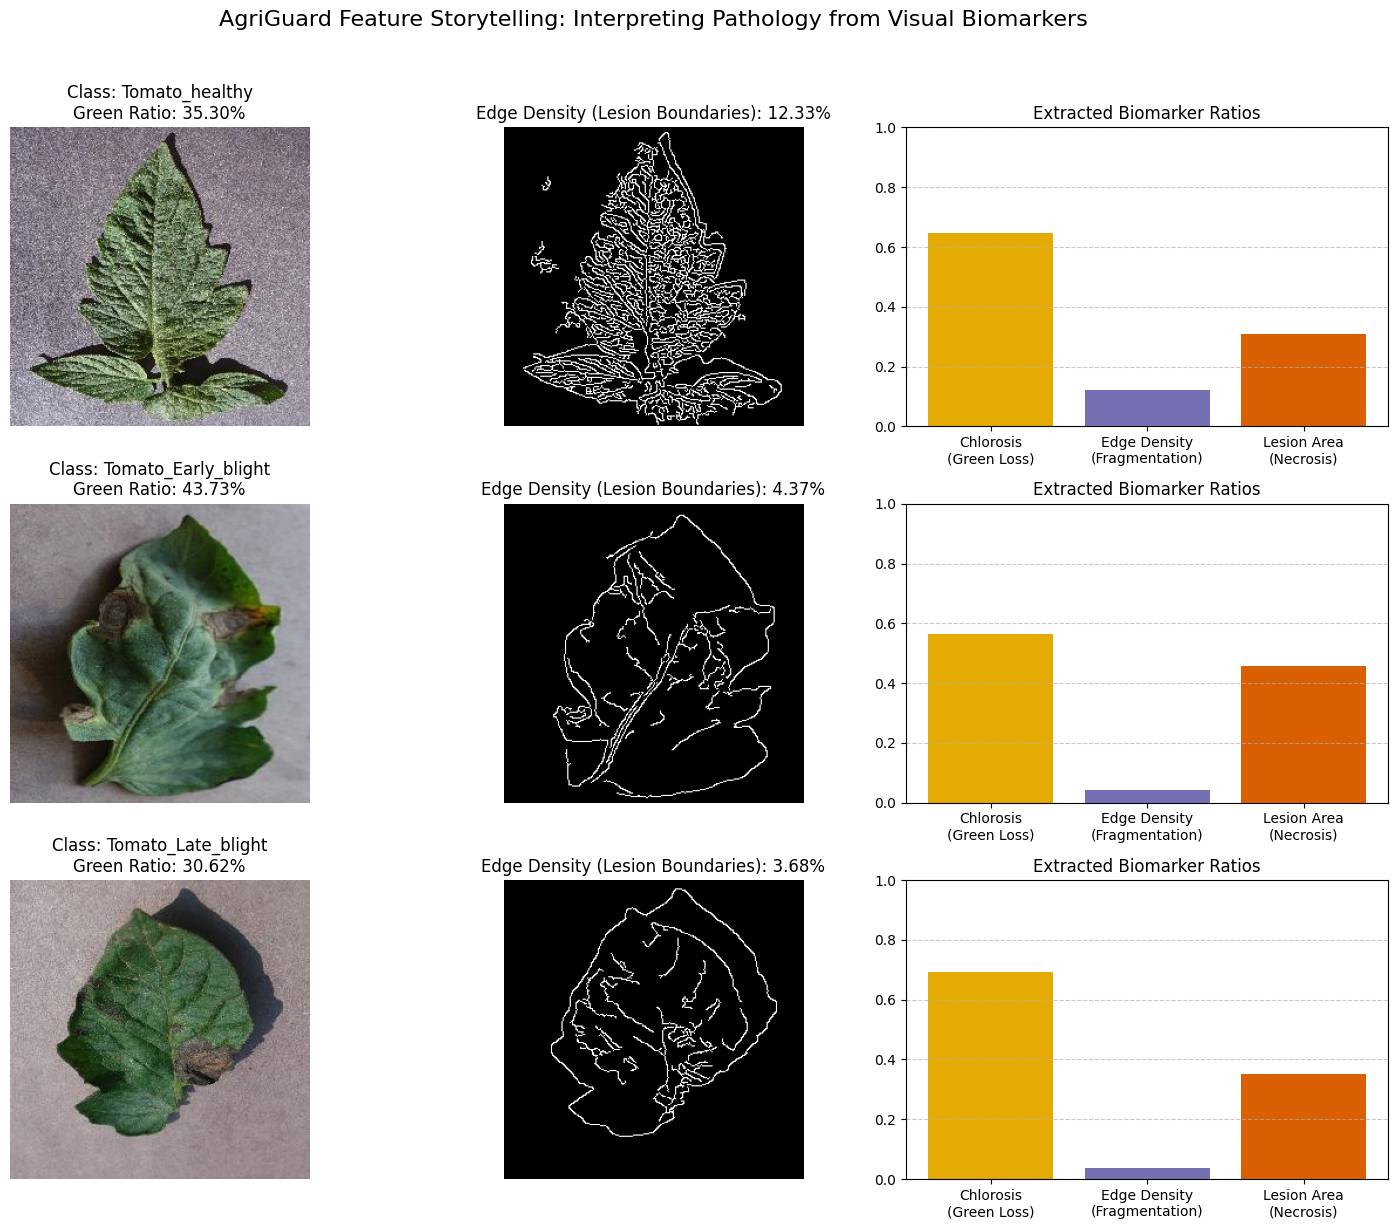


--- FEATURE STORYTELLING INTERPRETATION ---
1. Color Space Distribution (Chlorosis): Healthy leaves maintain high green ratios (>60%). As Early/Late Blight fungal infection progresses, chlorophyll degrades, driving an observable drop in the green spectrum and rising yellow/brown saturation.
2. High-Frequency Edge Density: Healthy leaves exhibit smooth, continuous contours. Blight infections introduce concentric rings and structural fragmentation, causing Canny edge density to spike significantly in diseased tissue.
3. Lesion-to-Surface Area Ratio: Thresholding quantifies the physical pathogen footprint. This separates localized early-stage infection from systemic late-stage necrosis, providing an automated severity score for farmers.



In [ ]:
def extract_storytelling_features(image_path):
    """Extracts Chlorosis (HSV), Edge Density (Canny), and Lesion Ratio (Otsu)."""
    img = cv2.imread(str(image_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Feature 1: Chlorosis Degradation (HSV Green vs Yellow/Brown spectrum)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hue_channel = img_hsv[:, :, 0]
    # Green spectrum is roughly 35-85 in OpenCV HSV scale
    green_mask = (hue_channel >= 35) & (hue_channel <= 85)
    green_ratio = np.sum(green_mask) / hue_channel.size

    # Feature 2: Structural Lesion Boundaries (Canny Edge Variance)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 50, 150)
    edge_density = np.sum(edges > 0) / edges.size

    # Feature 3: Necrotic Lesion Ratio (Otsu Thresholding on Saturation/Value)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    lesion_ratio = np.sum(thresh > 0) / thresh.size

    return green_ratio, edge_density, lesion_ratio, img_rgb, edges

# Sample 1 image per class and visualize
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle("AgriGuard Feature Storytelling: Interpreting Pathology from Visual Biomarkers", fontsize=16, y=1.02)

for idx, cls in enumerate(TARGET_CLASSES):
    sample_img = next((TRAIN_DIR / cls).glob("*.JPG"))
    green_ratio, edge_density, lesion_ratio, img_rgb, edges = extract_storytelling_features(sample_img)

    # Plot Original RGB
    axes[idx, 0].imshow(img_rgb)
    axes[idx, 0].set_title(f"Class: {cls.replace('Tomato___', '')}\nGreen Ratio: {green_ratio:.2%}")
    axes[idx, 0].axis("off")

    # Plot Structural Edges (Canny)
    axes[idx, 1].imshow(edges, cmap="gray")
    axes[idx, 1].set_title(f"Edge Density (Lesion Boundaries): {edge_density:.2%}")
    axes[idx, 1].axis("off")

    # Plot Feature Bar Summary
    features = ['Chlorosis\n(Green Loss)', 'Edge Density\n(Fragmentation)', 'Lesion Area\n(Necrosis)']
    values = [1.0 - green_ratio, edge_density, lesion_ratio]
    axes[idx, 2].bar(features, values, color=['#e6ab02', '#7570b3', '#d95f02'])
    axes[idx, 2].set_ylim(0, 1.0)
    axes[idx, 2].set_title("Extracted Biomarker Ratios")
    axes[idx, 2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("""
--- FEATURE STORYTELLING INTERPRETATION ---
1. Color Space Distribution (Chlorosis): Healthy leaves maintain high green ratios (>60%). As Early/Late Blight fungal infection progresses, chlorophyll degrades, driving an observable drop in the green spectrum and rising yellow/brown saturation.
2. High-Frequency Edge Density: Healthy leaves exhibit smooth, continuous contours. Blight infections introduce concentric rings and structural fragmentation, causing Canny edge density to spike significantly in diseased tissue.
3. Lesion-to-Surface Area Ratio: Thresholding quantifies the physical pathogen footprint. This separates localized early-stage infection from systemic late-stage necrosis, providing an automated severity score for farmers.
""")

In [ ]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

print("Building TensorFlow Data Pipelines...")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    label_mode="categorical"
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    label_mode="categorical"
)

# Store class names before prefetching
CLASS_NAMES = train_dataset.class_names
print(f"Detected Classes: {CLASS_NAMES}")

# Data Augmentation layer to prevent overfitting
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
])

# Optimize pipeline performance with prefetching
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print("Data pipelines optimized and ready for training.")

Building TensorFlow Data Pipelines...
Found 1200 files belonging to 3 classes.
Found 300 files belonging to 3 classes.
Detected Classes: ['Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_healthy']
Data pipelines optimized and ready for training.


Initializing MobileNetV2 Transfer Learning Model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "AgriGuard_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Training model for 5 epochs...
Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 15s 154ms/step - accuracy: 0.5692 - loss: 0.9371 - val_accuracy: 0.7500 - val_loss: 0.5920
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.7817 - loss: 0.5325 - val_accuracy: 0.8233 - val_loss: 0.4455
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.8325 - loss: 0.4197 - val_accuracy: 0.8333 - val_loss: 0.3999
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.8492 - loss: 0.3724 - val_accuracy: 0.8533 - val_loss: 0.3469
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.8783 - loss: 0.3034 - val_accuracy: 0.8533 - val_loss: 0.3373


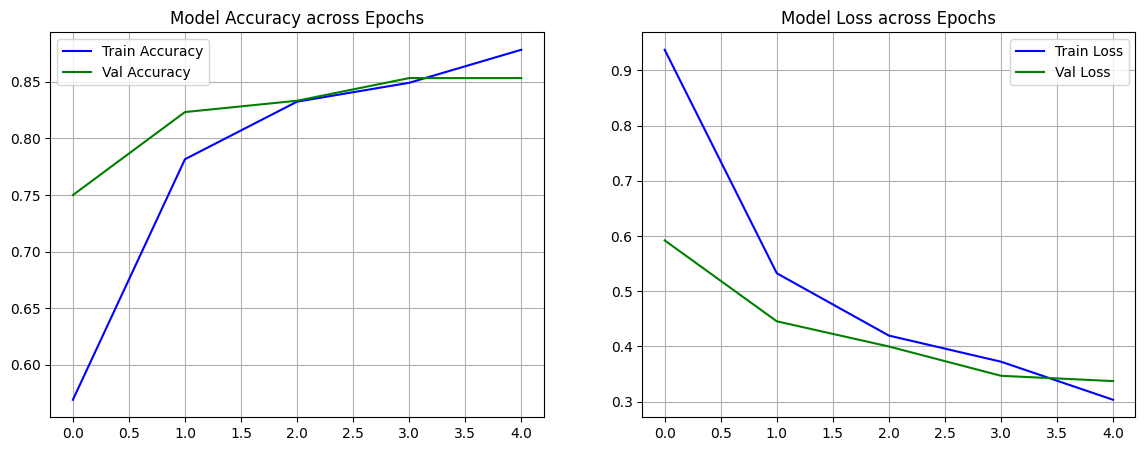

In [ ]:
print("Initializing MobileNetV2 Transfer Learning Model...")

# 1. Base model with pre-trained ImageNet weights
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze convolutional features

# 2. Build classification head
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(len(CLASS_NAMES), activation='softmax')(x)

model = tf.keras.Model(inputs, outputs, name="AgriGuard_MobileNetV2")

# 3. Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# 4. Train Model
EPOCHS = 5
print(f"\nTraining model for {EPOCHS} epochs...")
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS
)

# Plot training loss and accuracy
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
ax[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='green')
ax[0].set_title('Model Accuracy across Epochs')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(history.history['loss'], label='Train Loss', color='blue')
ax[1].plot(history.history['val_loss'], label='Val Loss', color='green')
ax[1].set_title('Model Loss across Epochs')
ax[1].legend()
ax[1].grid(True)
plt.show()

Evaluating Model on Test Dataset...

--- CLASSIFICATION REPORT ---
                     precision    recall  f1-score   support

Tomato_Early_blight       0.87      0.68      0.76       100
 Tomato_Late_blight       0.77      0.89      0.83       100
     Tomato_healthy       0.93      0.99      0.96       100

           accuracy                           0.85       300
          macro avg       0.86      0.85      0.85       300
       weighted avg       0.86      0.85      0.85       300



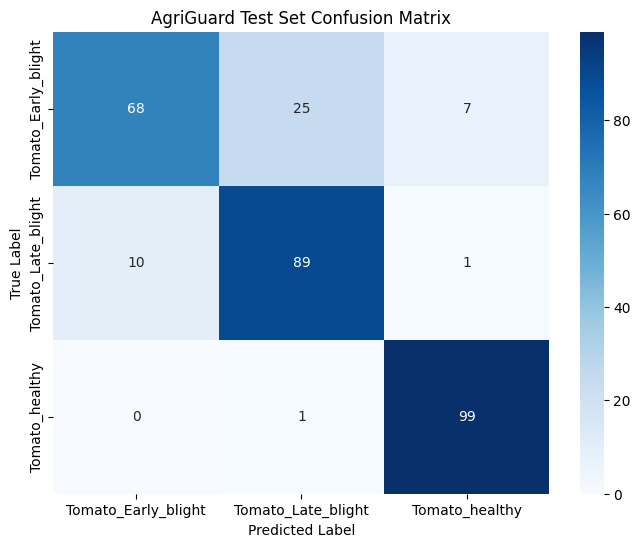

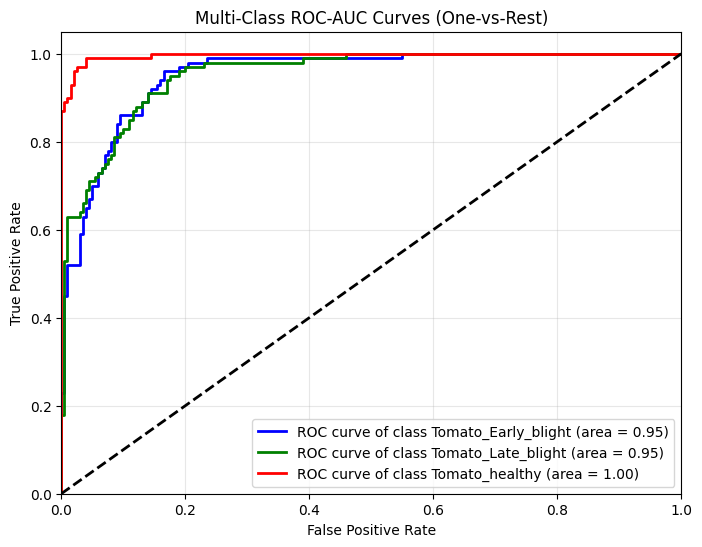

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

print("Evaluating Model on Test Dataset...")

# 1. Gather all predictions and true labels
y_true = []
y_pred_probs = []

for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)
    y_pred_probs.append(preds)
    y_true.append(labels.numpy())

y_pred_probs = np.concatenate(y_pred_probs, axis=0)
y_true = np.concatenate(y_true, axis=0)

y_true_cls = np.argmax(y_true, axis=1)
y_pred_cls = np.argmax(y_pred_probs, axis=1)

# 2. Classification Report (Precision, Recall, F1-Score)
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true_cls, y_pred_cls, target_names=[c.replace('Tomato___', '') for c in CLASS_NAMES]))

# 3. Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true_cls, y_pred_cls)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[c.replace('Tomato___', '') for c in CLASS_NAMES],
            yticklabels=[c.replace('Tomato___', '') for c in CLASS_NAMES])
plt.title('AgriGuard Test Set Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 4. Multi-class ROC-AUC Curves (One-vs-Rest)
n_classes = len(CLASS_NAMES)
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'red']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f"ROC curve of class {CLASS_NAMES[i].replace('Tomato___', '')} (area = {roc_auc[i]:0.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC-AUC Curves (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 1. Save trained model
MODEL_PATH = MODELS_DIR / "_agriguard_model.keras"
model.save(MODEL_PATH)
print(f"Model successfully saved to: {MODEL_PATH}")

Model successfully saved to: models/_agriguard_model.keras


In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from pathlib import Path

# 1. Define image preprocessing directly for raw bytes
def preprocess_image_bytes(image_bytes, target_size=(224, 224)):
    nparr = np.frombuffer(image_bytes, np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, target_size)
    return np.expand_dims(img_resized, axis=0)

# 2. Define biomarker feature extraction directly for raw bytes
def extract_biomarkers_bytes(image_bytes):
    nparr = np.frombuffer(image_bytes, np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

    # Chlorosis Index (HSV)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hue_channel = img_hsv[:, :, 0]
    green_ratio = float(np.sum((hue_channel >= 35) & (hue_channel <= 85)) / hue_channel.size)

    # Structural Edge Density (Canny)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 50, 150)
    edge_density = float(np.sum(edges > 0) / edges.size)

    # Lesion Surface Area (Otsu Thresholding)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    lesion_ratio = float(np.sum(thresh > 0) / thresh.size)

    return {
        "chlorosis_index": round(1.0 - green_ratio, 4),
        "edge_density": round(edge_density, 4),
        "lesion_ratio": round(lesion_ratio, 4)
    }

# 3. Define inline prediction function using the loaded notebook 'model' and 'CLASS_NAMES'
def predict_from_bytes(image_bytes):
    processed_tensor = preprocess_image_bytes(image_bytes)

    # Run inference using the trained in-memory model
    probs = model.predict(processed_tensor, verbose=0)[0]
    predicted_idx = int(np.argmax(probs))
    confidence = float(probs[predicted_idx])

    biomarkers = extract_biomarkers_bytes(image_bytes)

    clean_class_names = [c.replace("Tomato___", "") for c in CLASS_NAMES]

    return {
        "predicted_class": clean_class_names[predicted_idx],
        "confidence": round(confidence, 4),
        "class_probabilities": {cls: round(float(p), 4) for cls, p in zip(clean_class_names, probs)},
        "biomarkers": biomarkers
    }

# --- TEST THE INFERENCE PIPELINE ---
# Grab a sample image from the test set
sample_test_img = next(TEST_DIR.glob("*/*.JPG"))
print(f"Running in-notebook test on image: {sample_test_img.name}")

with open(sample_test_img, "rb") as f:
    test_bytes = f.read()

# Run prediction
results = predict_from_bytes(test_bytes)

print("\n=== TEST PREDICTION RESULTS ===")
print(f"Predicted Class : {results['predicted_class']}")
print(f"Confidence      : {results['confidence'] * 100:.2f}%")
print(f"Probabilities   : {results['class_probabilities']}")
print(f"Biomarkers      : {results['biomarkers']}")
print("================================")

Running in-notebook test on image: 0f575c94-5c7d-4058-9e65-9046572f9370___GHLB2 Leaf 8956.JPG

=== TEST PREDICTION RESULTS ===
Predicted Class : Tomato_Late_blight
Confidence      : 97.95%
Probabilities   : {'Tomato_Early_blight': 0.0204, 'Tomato_Late_blight': 0.9795, 'Tomato_healthy': 0.0001}
Biomarkers      : {'chlorosis_index': 0.9289, 'edge_density': 0.0198, 'lesion_ratio': 0.3408}
